# Vitamin Deficiency Prediction
This notebook contains a complete workflow for building a vitamin deficiency prediction model.

## 1. Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Dataset

In [3]:
DATA_PATH = 'Data/data.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
df.head()

Shape: (3500, 21)


,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,0.0000
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,0.8440
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,0.0040
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,0.7724
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,0.3720


## 3. Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   object 
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   object 
 4   alcohol_consumption      2390 non-null   object 
 5   exercise_level           3500 non-null   object 
 6   diet_type                3500 non-null   object 
 7   sun_exposure             3500 non-null   object 
 8   income_level             3500 non-null   object 
 9   latitude_region          3500 non-null   object 
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda 

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,3500.0,50.591714,19.279577,18.0,34.0000,50.000,67.00000,84.00
bmi,3500.0,26.098914,4.944079,15.0,22.8000,26.200,29.40000,43.90
vitamin_a_percent_rda,3500.0,90.682286,37.146999,10.0,62.3750,85.500,115.12500,219.00
vitamin_c_percent_rda,3500.0,88.571914,37.190350,10.0,60.7000,83.400,111.72500,230.50
vitamin_d_percent_rda,3500.0,72.416666,42.994453,7.0,40.6975,62.300,93.81500,275.60
vitamin_e_percent_rda,3500.0,89.676914,37.216509,10.0,61.5000,84.000,114.02500,237.60
vitamin_b12_percent_rda,3500.0,62.704571,37.441959,10.0,32.6000,55.900,84.50000,243.60
folate_percent_rda,3500.0,90.196771,37.279605,10.0,62.0000,84.600,114.75000,226.60
calcium_percent_rda,3500.0,82.364057,36.058349,10.0,55.6000,76.700,104.82500,232.70
iron_percent_rda,3500.0,76.417686,32.904281,10.0,51.7750,71.550,96.00000,211.40


In [6]:
df.isnull().sum()

age                           0
gender                        0
bmi                           0
smoking_status                0
alcohol_consumption        1110
exercise_level                0
diet_type                     0
sun_exposure                  0
income_level                  0
latitude_region               0
vitamin_a_percent_rda         0
vitamin_c_percent_rda         0
vitamin_d_percent_rda         0
vitamin_e_percent_rda         0
vitamin_b12_percent_rda       0
folate_percent_rda            0
calcium_percent_rda           0
iron_percent_rda              0
symptoms_count                0
symptoms_list              1152
vitamin_deficiency            0
dtype: int64

- alcohol_consumption  =1110
- symptoms_list  = 1152

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

age                          int64
gender                      object
bmi                        float64
smoking_status              object
alcohol_consumption         object
exercise_level              object
diet_type                   object
sun_exposure                object
income_level                object
latitude_region             object
vitamin_a_percent_rda      float64
vitamin_c_percent_rda      float64
vitamin_d_percent_rda      float64
vitamin_e_percent_rda      float64
vitamin_b12_percent_rda    float64
folate_percent_rda         float64
calcium_percent_rda        float64
iron_percent_rda           float64
symptoms_count               int64
symptoms_list               object
vitamin_deficiency         float64
dtype: object

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

## 4. Exploratory Data Analysis (EDA)

In [10]:
histo_cols = numeric_cols.copy()
histo_cols.remove('symptoms_count')
#histo_cols.append('symptoms_list')


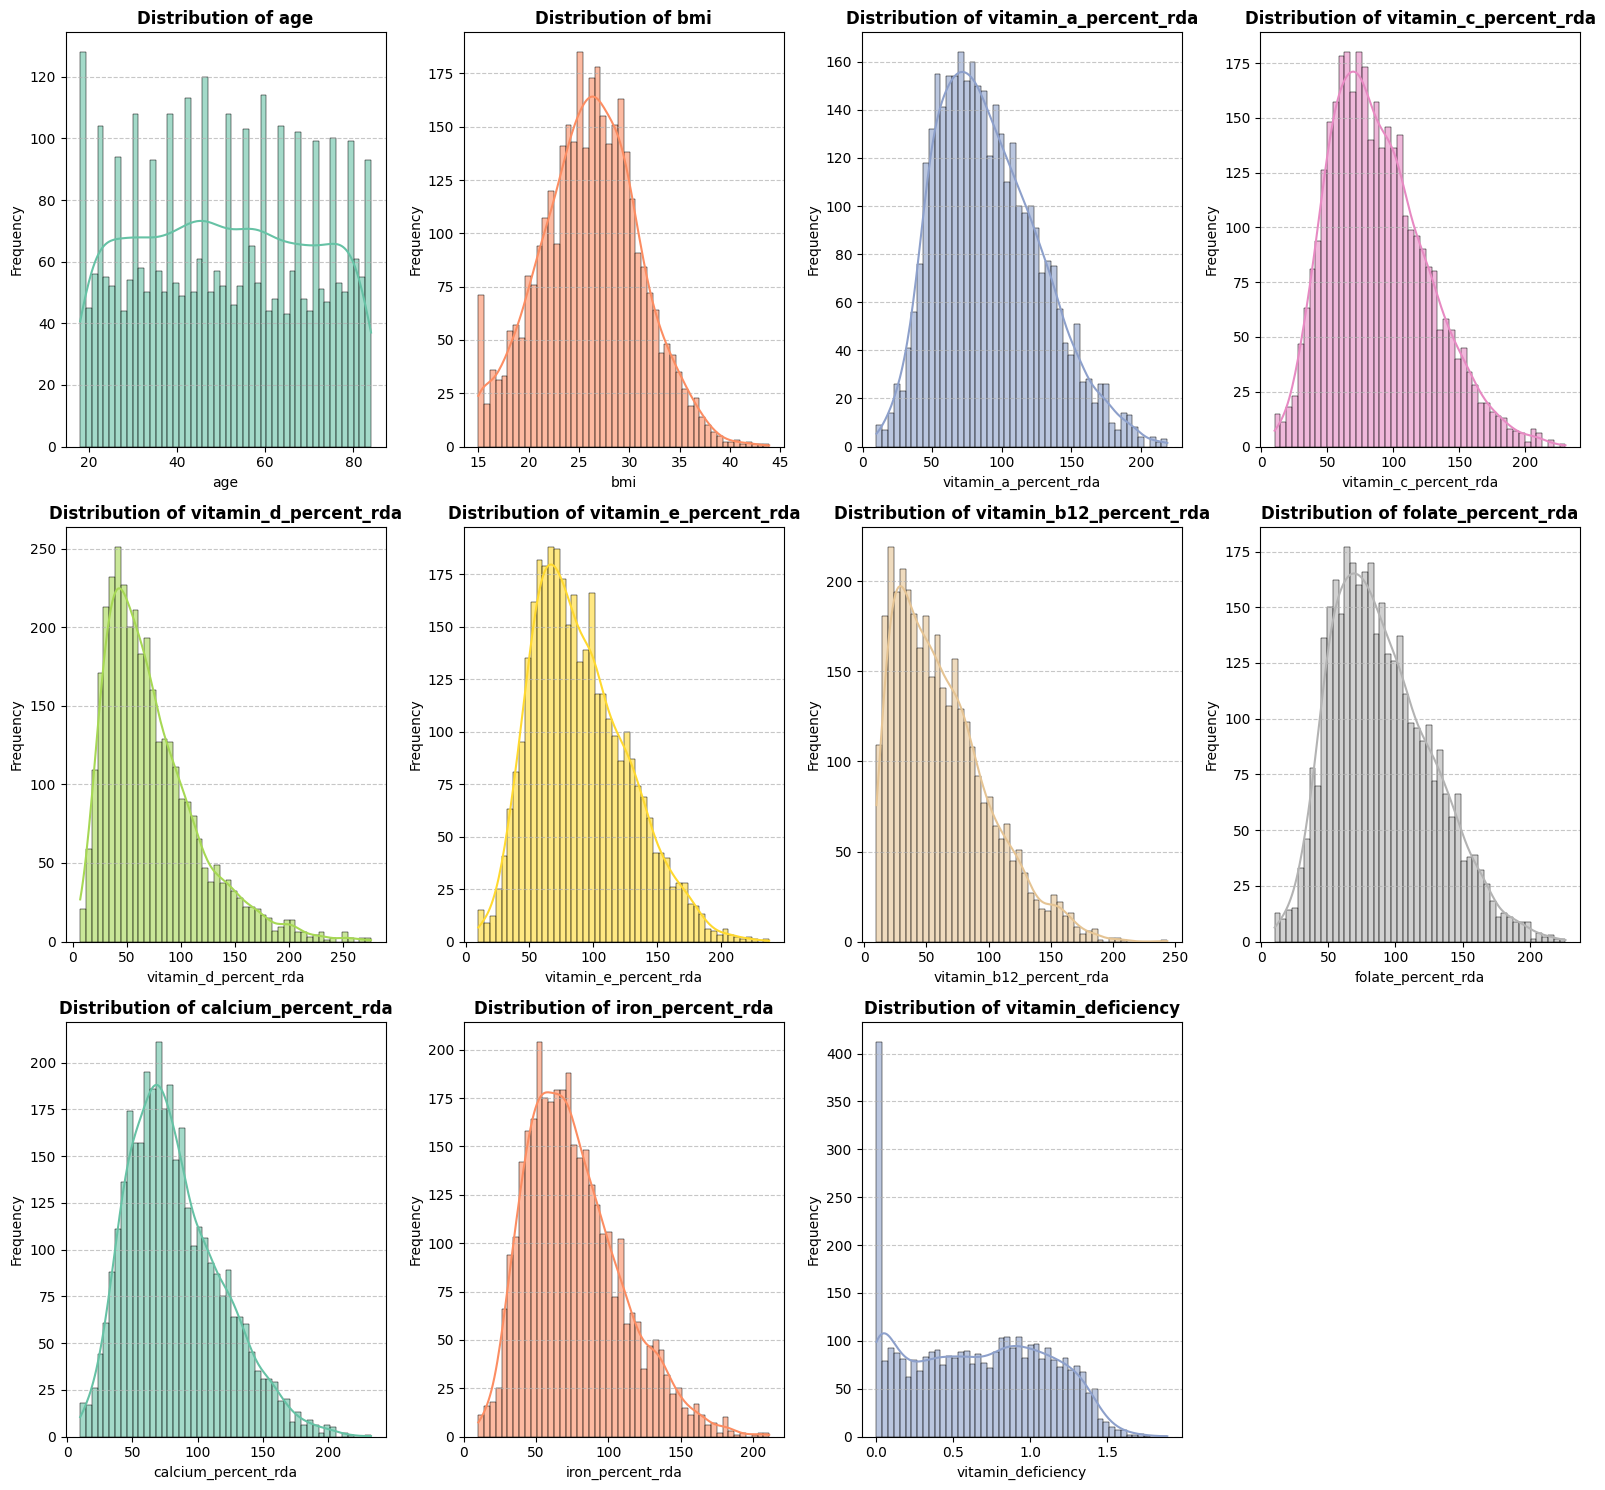

In [11]:
import math
cols_per_row = 4
num_rows = math.ceil(len(histo_cols) / cols_per_row)
fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(16, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(histo_cols):
    sns.histplot(data=df, x=col,kde=True,bins=50, alpha=0.6, color=sns.color_palette("Set2")[i % 8], ax=axes[i])        
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(histo_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

plt.show()

In [12]:
count_plot_cols = categorical_cols.copy()
count_plot_cols.remove('symptoms_list')

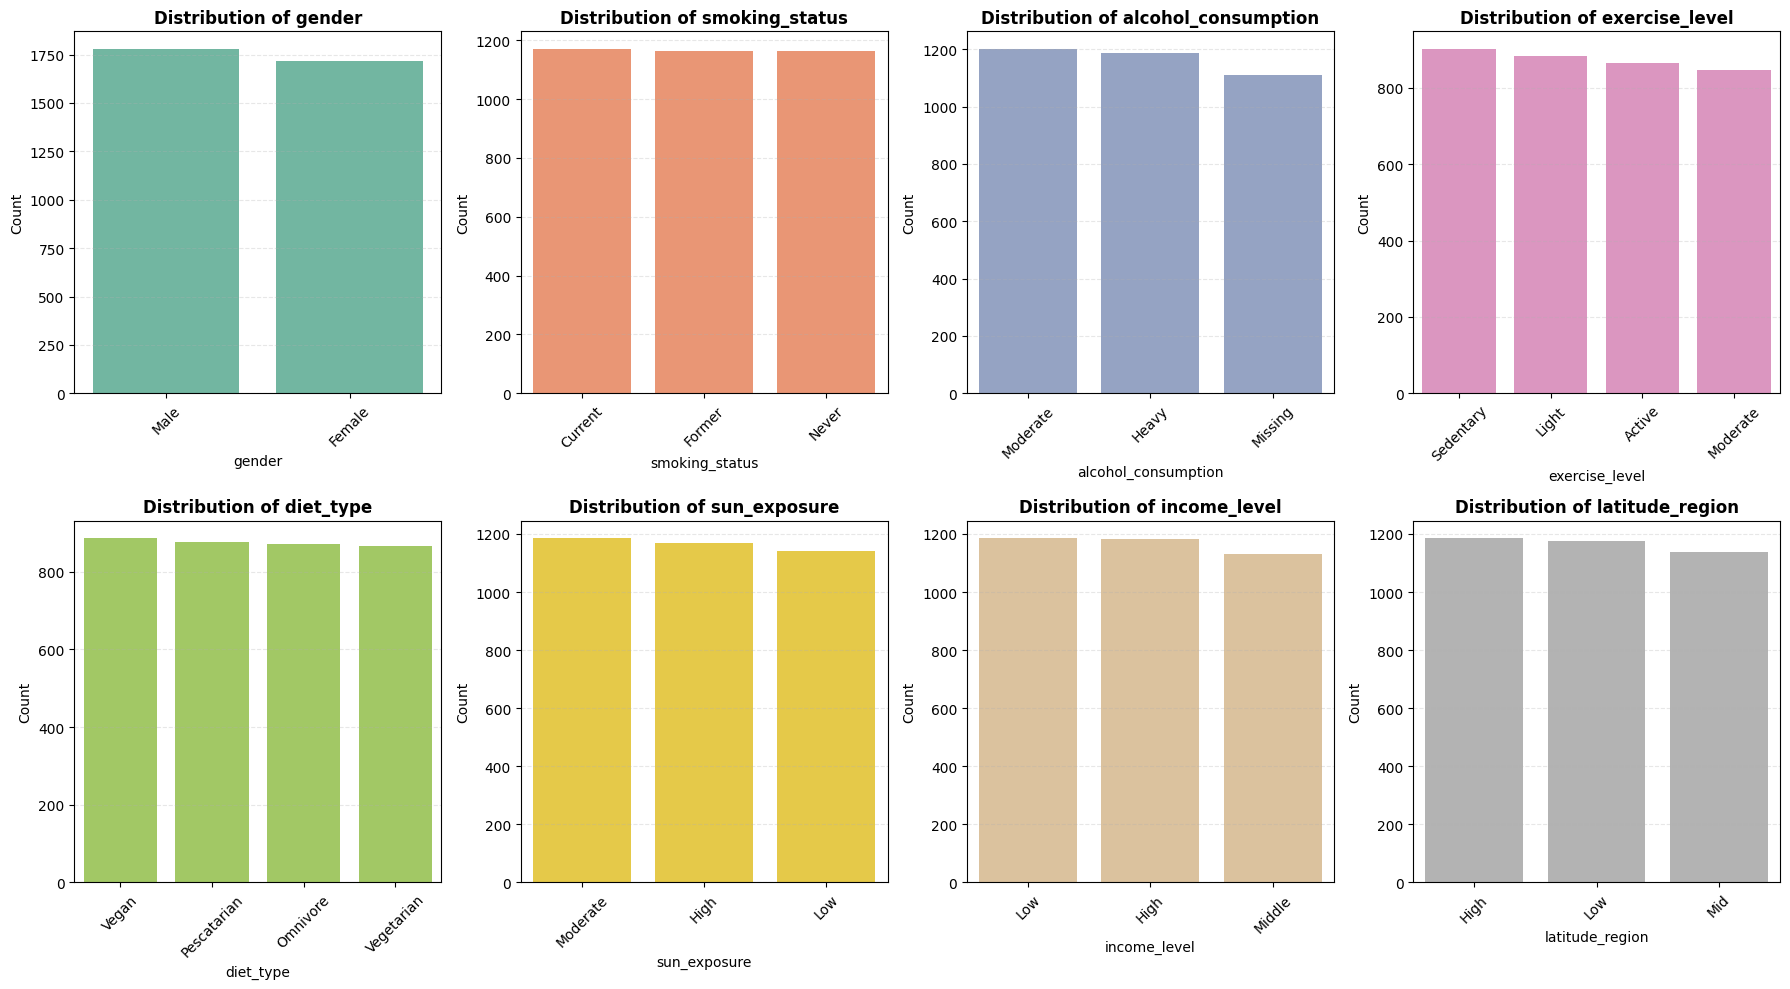

In [13]:
cols_per_row = 4
num_rows = math.ceil(len(count_plot_cols) / cols_per_row)

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=cols_per_row,
    figsize=(18, 5 * num_rows)
)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(count_plot_cols):
    ax = axes[i]
    series = df[col].fillna("Missing").astype(str)

    if series.nunique() > 15:
        top_values = series.value_counts().nlargest(15).index
        series = series.where(series.isin(top_values), "Other")

    order = series.value_counts().index
    sns.countplot(x=series, order=order, ax=ax, color=sns.color_palette("Set2")[i % 8])

    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for j in range(len(count_plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [14]:
df_encoded = df.copy()
encoder = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = encoder.fit_transform(df[col].fillna("Missing").astype(str))
final_corr_df = df_encoded[numeric_cols + categorical_cols]
corr_matrix = final_corr_df.corr()

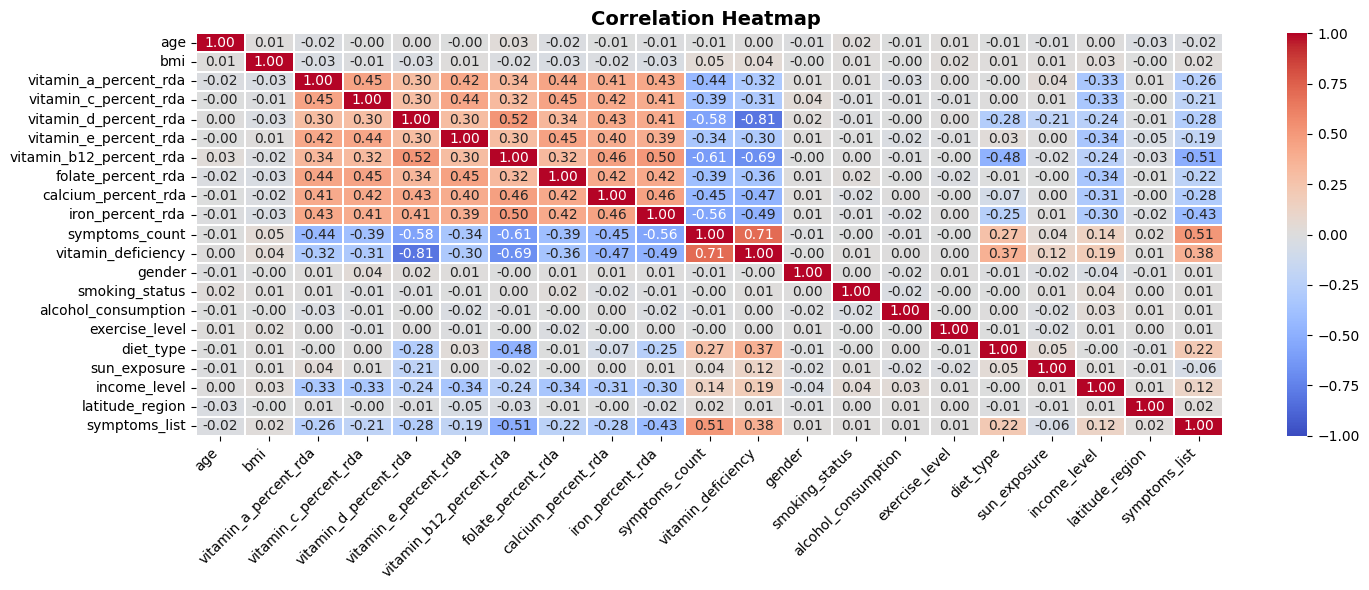

In [15]:
plt.figure(figsize=(15, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f", cmap='coolwarm', linewidths=0.1,
    vmin=-1, vmax=1,
    linecolor='white'
)

plt.title('Correlation Heatmap ', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Preprocessing

In [16]:
model_data = corr_matrix[["symptoms_list", 'symptoms_count', 'diet_type','vitamin_deficiency']]

## 6. Train/Test Split and Scaling

In [17]:
x_train, x_test, y_train, y_test = train_test_split( model_data.drop("vitamin_deficiency", axis=1), model_data["vitamin_deficiency"],test_size=0.2,random_state=42
)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 7. Model Training

In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
y_pred = rf.predict(x_test_scaled)
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

R-squared: 0.8997
Mean Squared Error: 0.0044


In [19]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

R-squared: 0.9637
Mean Squared Error: 0.0016


## 8. Evaluation